## Time Series Data Analysis

Problem statement: Analysis and Visualization of Stock Market Data
Dataset: "Stock_Prices.csv"
Description: The dataset contains historical stock price data for a particular company over a
period of time. It includes attributes such as date, closing price, volume, and other relevant
features. The goal is to perform time series data analysis on the stock price data to identify
trends, patterns, and potential predictors, as well as build models to forecast future stock
prices.
Tasks to Perform:
1. Import the "Stock_Prices.csv" dataset.
2. Explore the dataset to understand its structure and content.
3. Ensure that the date column is in the appropriate format (e.g., datetime) for time series
analysis.
4. Plot line charts or time series plots to visualize the historical stock price trends over
time.
5. Calculate and plot moving averages or rolling averages to identify the underlying
trends and smooth out noise.
6. Perform seasonality analysis to identify periodic patterns in the stock prices, such as
weekly, monthly, or yearly fluctuations.
7. Analyze and plot the correlation between the stock prices and other variables, such as
trading volume or market indices.
8. Use autoregressive integrated moving average (ARIMA) models or exponential
smoothing models to forecast future stock prices.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose  # <-- Add this line
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [17]:
df = pd.read_csv('NSE-Tata_Global_Beverages_Limited.csv')

## 2.Explore the dataset to understand its structure and content.

In [18]:
df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
1,2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2,2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
3,2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
4,2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05


In [19]:
df.shape

(1235, 8)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1235 non-null   object 
 1   Open                  1235 non-null   float64
 2   High                  1235 non-null   float64
 3   Low                   1235 non-null   float64
 4   Last                  1235 non-null   float64
 5   Close                 1235 non-null   float64
 6   Total Trade Quantity  1235 non-null   float64
 7   Turnover (Lacs)       1235 non-null   float64
dtypes: float64(7), object(1)
memory usage: 77.3+ KB


In [21]:
df.describe()

,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
count,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1.235000e+03,1235.000000
mean,168.954858,171.429069,166.402308,168.736356,168.731053,2.604151e+06,4843.166502
std,51.499145,52.436761,50.542919,51.587384,51.544928,2.277028e+06,5348.919832
min,103.000000,104.600000,100.000000,102.600000,102.650000,1.001800e+05,128.040000
25%,137.550000,138.925000,135.250000,137.175000,137.225000,1.284482e+06,1801.035000
50%,151.500000,153.250000,149.500000,151.200000,151.100000,1.964885e+06,3068.510000
75%,169.000000,172.325000,166.700000,169.100000,169.500000,3.095788e+06,5852.600000
max,327.700000,328.750000,321.650000,325.950000,325.750000,2.919102e+07,55755.080000


In [22]:
df.isnull().sum()

Date                    0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
Total Trade Quantity    0
Turnover (Lacs)         0
dtype: int64

In [23]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Last', 'Close', 'Total Trade Quantity',
       'Turnover (Lacs)'],
      dtype='object')

## 3. Ensure that the date column is in the appropriate format (e.g., datetime) for time series analysis.

In [24]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [25]:
df.head()

,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
Date,,,,,,,
2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05


## 4. Plot line charts or time series plots to visualize the historical stock price trends over time.

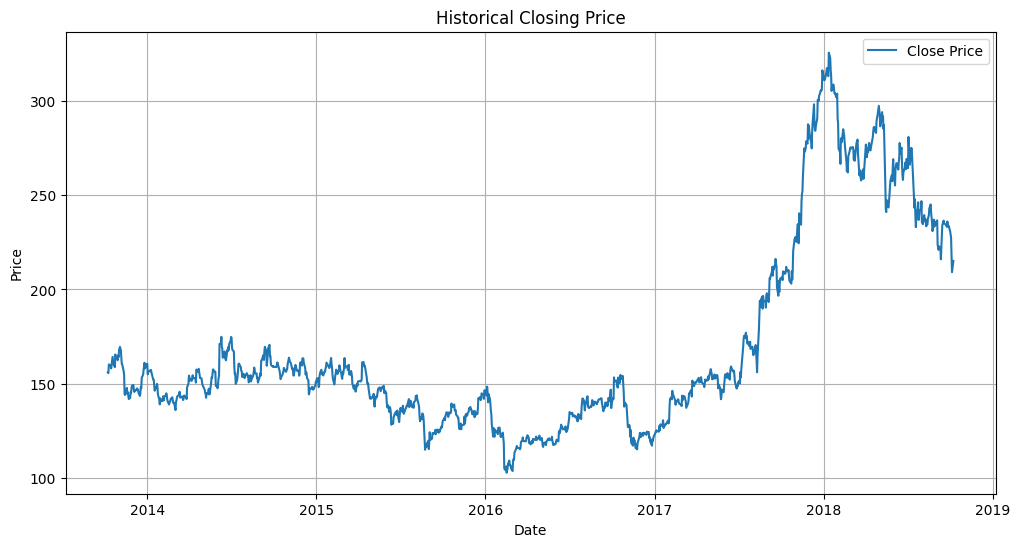

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price')
plt.title('Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

## 5. Calculate and plot moving averages or rolling averages to identify the underlying trends and smooth out noise.

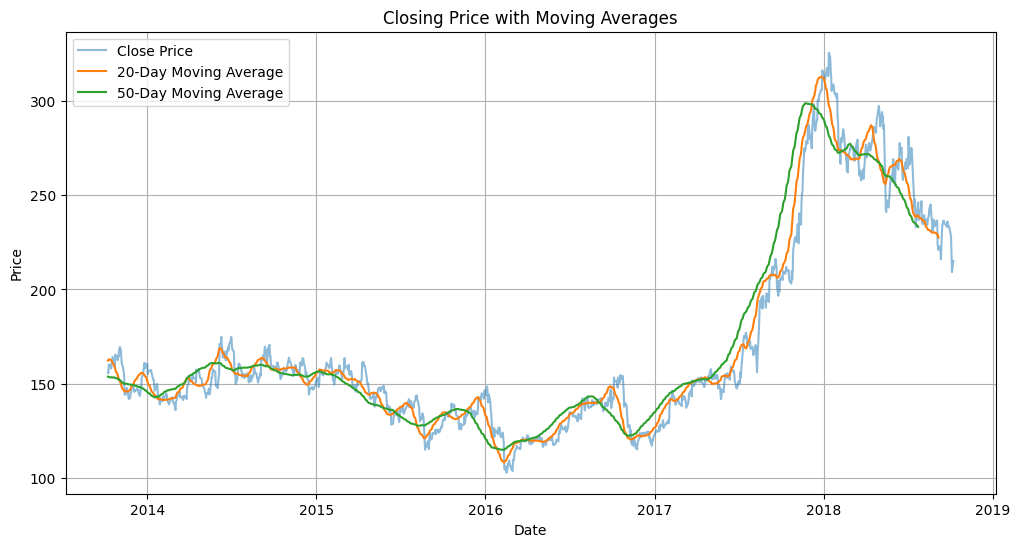

In [29]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price', alpha=0.5)
plt.plot(df['MA_20'], label='20-Day Moving Average')
plt.plot(df['MA_50'], label='50-Day Moving Average')
plt.title('Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


## 6. Perform seasonality analysis to identify periodic patterns in the stock prices, such as weekly, monthly, or yearly fluctuations.

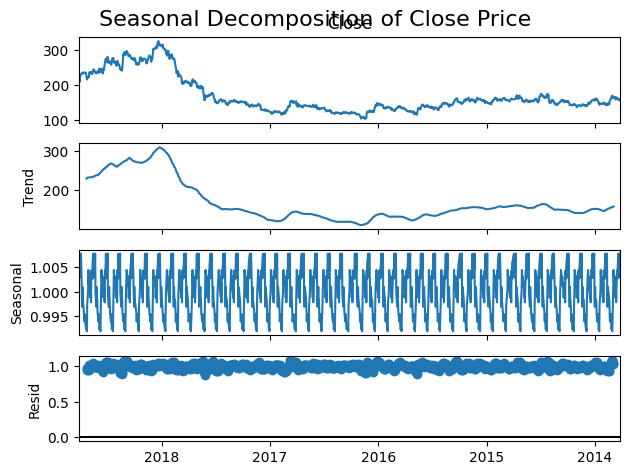

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose

# The seasonal_decompose function is a crucial tool in time series analysis, used for decomposing a time series into its constituent components: trend, seasonal, and residual. It is part of the statsmodels library in Python and specifically resides within the statsmodels.tsa.seasonal module.

result = seasonal_decompose(df['Close'].dropna(), model='multiplicative', period=30)
result.plot()
plt.suptitle('Seasonal Decomposition of Close Price', fontsize=16)
plt.show()

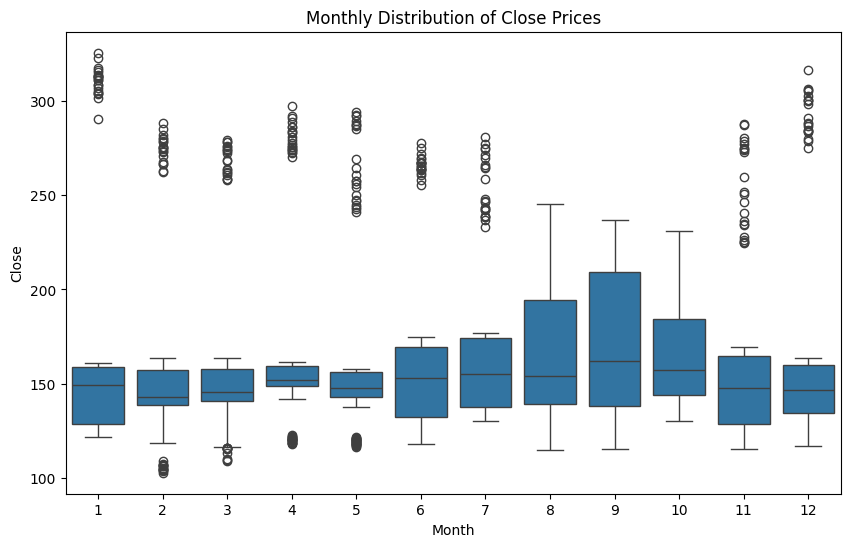

In [40]:
df['Month'] = df.index.month
plt.figure(figsize=(10,6))
sns.boxplot(x='Month', y='Close', data=df)
plt.title('Monthly Distribution of Close Prices')
plt.show()

## 7. Analyze and plot the correlation between the stock prices and other variables, such as trading volume or market indices.


Correlation matrix:
                         Close  Total Trade Quantity  Turnover (Lacs)
Close                 1.000000              0.380801         0.599155
Total Trade Quantity  0.380801              1.000000         0.941976
Turnover (Lacs)       0.599155              0.941976         1.000000


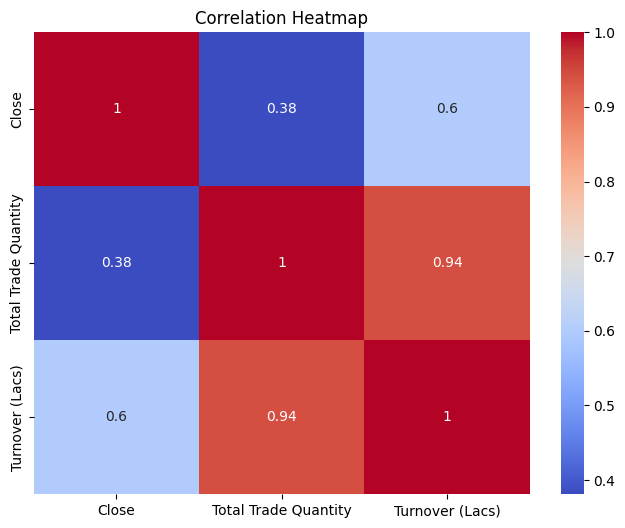

In [41]:
corr_df = df[['Close', 'Total Trade Quantity', 'Turnover (Lacs)']]
print("\nCorrelation matrix:")
print(corr_df.corr())

plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 8. Use autoregressive integrated moving average (ARIMA) models or exponential smoothing models to forecast future stock prices.

In [42]:
# Prepare data
data = df['Close'].dropna()

In [43]:
# Split train-test
train_size = int(len(data)*0.8)
train, test = data[:train_size], data[train_size:]

In [44]:
# Fit ARIMA model (order can be adjusted)
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

In [45]:
# Forecast
forecast = model_fit.forecast(steps=len(test))

In [47]:
forecast

988     161.279048
989     161.244326
990     161.222665
991     161.149672
992     161.124885
           ...    
1230    161.125795
1231    161.125795
1232    161.125795
1233    161.125795
1234    161.125795
Name: predicted_mean, Length: 247, dtype: float64

In [48]:
# Evaluate
mse = mean_squared_error(test, forecast)
print(f"\nMean Squared Error (ARIMA Forecast): {mse:.4f}")


Mean Squared Error (ARIMA Forecast): 135.0314


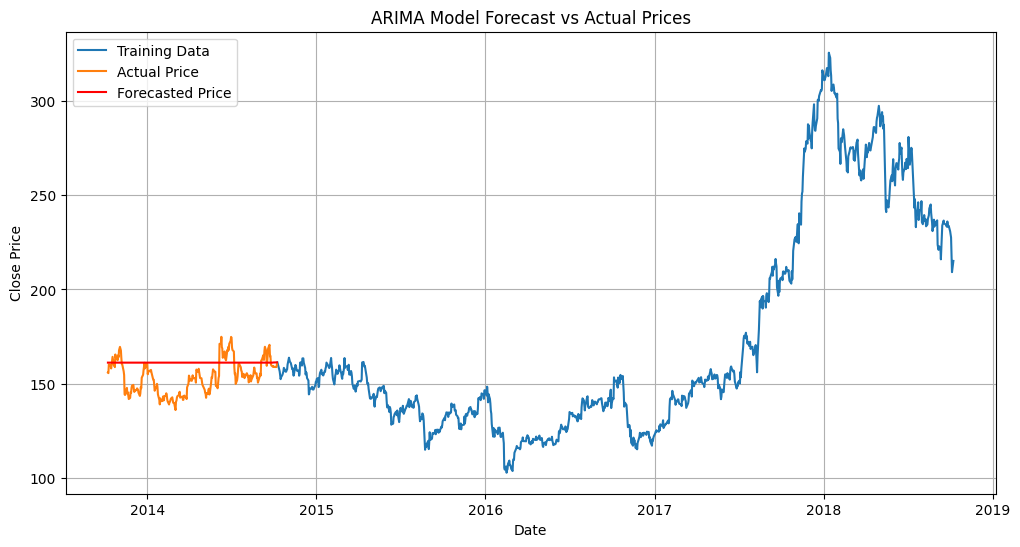

In [50]:
# Plot forecast vs actual
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Price')
plt.plot(test.index, forecast, label='Forecasted Price', color='red')
plt.title('ARIMA Model Forecast vs Actual Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()